# State-Dependent U.S. Equity Sector Rotation
## A Systematic Framework for Trend-Based Active Sector Allocation

# Block 7 — Visual Diagnostics & Research Interpretation

Block 7 converts the validated return, turnover, drawdown, and attribution outputs into a research-quality diagnostic package.

The goal is not simply to produce more charts. The visual layer is designed to answer:

- Did the state-dependent strategy outperform SPY, the inverse-volatility strategic baseline, and conventional 12-month TSMOM?
- Was any outperformance persistent or concentrated in a few episodes?
- Did the strategy improve drawdowns or merely add return?
- Was active performance driven by a small number of sectors?
- How much additional turnover did the state-dependent process require?
- When did the state-dependent model outperform or underperform TSMOM?
- Were active returns associated with particular strategic or tactical states?

This block introduces **no new trading rules or optimization**.


In [1]:
# ============================================================
# BLOCK 7.1 — ENVIRONMENT, DRIVE & PRIOR MANIFESTS
# ============================================================

from pathlib import Path
from google.colab import drive
import json
from datetime import datetime, timezone

drive.mount("/content/drive")

PROJECT_ROOT = Path("/content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation")

DIRS = {
    "root": PROJECT_ROOT,
    "data_processed": PROJECT_ROOT / "data" / "processed",
    "outputs": PROJECT_ROOT / "outputs",
    "tables": PROJECT_ROOT / "outputs" / "tables",
    "figures": PROJECT_ROOT / "outputs" / "figures",
    "manifests": PROJECT_ROOT / "manifests",
}

for p in DIRS.values():
    p.mkdir(parents=True, exist_ok=True)

manifest_names = {
    "block1": "block_1_research_configuration.json",
    "block2": "block_2_universe_data_weights.json",
    "block3": "block_3_signal_engine.json",
    "block4": "block_4_state_active_weights.json",
    "block5": "block_5_portfolio_engine.json",
    "block6": "block_6_performance_analytics.json",
}

manifests = {}

for key, filename in manifest_names.items():
    path = DIRS["manifests"] / filename
    if not path.exists():
        raise FileNotFoundError(f"Required manifest not found: {path}")
    with open(path, "r", encoding="utf-8") as f:
        manifests[key] = json.load(f)

block1 = manifests["block1"]
block2 = manifests["block2"]
block3 = manifests["block3"]
block4 = manifests["block4"]
block5 = manifests["block5"]
block6 = manifests["block6"]

CONFIG = block1["research_config"]
SECTOR_RECORDS = block1["sector_universe"]
SECTOR_TICKERS = [x["ticker"] for x in SECTOR_RECORDS]

assert block5["strategic_weight_method"] == "INVERSE_VOLATILITY_52W"

print("Loaded and validated Blocks 1–6.")
print(
    "Realized execution window:",
    block6["realized_execution_window"]["start"],
    "to",
    block6["realized_execution_window"]["end"],
)


Mounted at /content/drive
Loaded and validated Blocks 1–6.
Realized execution window: 2019-06-24 to 2026-08-24


In [2]:
# ============================================================
# BLOCK 7.2 — IMPORTS & LOAD ANALYTICS / STATE OUTPUTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)

PORTFOLIO_RETURNS_PATH = Path(
    block5["saved_files"]["portfolio_returns"]
)
TURNOVER_PATH = Path(
    block5["saved_files"]["portfolio_turnover"]
)
STATE_LONG_PATH = Path(
    block4["saved_files"]["state_signal_long"]
)
STATE_WEIGHT_LONG_PATH = Path(
    block4["saved_files"]["canonical_active_weights_long"]
)
SECTOR_ATTRIBUTION_WEEKLY_PATH = Path(
    block6["saved_files"]["state_sector_attribution_weekly"]
)

for p in [
    PORTFOLIO_RETURNS_PATH,
    TURNOVER_PATH,
    STATE_LONG_PATH,
    STATE_WEIGHT_LONG_PATH,
    SECTOR_ATTRIBUTION_WEEKLY_PATH,
]:
    if not p.exists():
        raise FileNotFoundError(f"Required Block 7 input not found: {p}")

portfolio_returns = pd.read_parquet(PORTFOLIO_RETURNS_PATH)
turnover = pd.read_parquet(TURNOVER_PATH)
state_long = pd.read_parquet(STATE_LONG_PATH)
state_weight_long = pd.read_parquet(STATE_WEIGHT_LONG_PATH)
state_sector_contrib = pd.read_parquet(SECTOR_ATTRIBUTION_WEEKLY_PATH)

for obj in [portfolio_returns, turnover, state_sector_contrib]:
    obj.index = pd.to_datetime(obj.index)
    obj.sort_index(inplace=True)

state_long["date"] = pd.to_datetime(state_long["date"])
state_weight_long["date"] = pd.to_datetime(state_weight_long["date"])

EXPECTED_PORTFOLIOS = [
    "SPY",
    "Strategic_IV",
    "TSMOM_12M",
    "State_Dependent",
]

assert portfolio_returns[EXPECTED_PORTFOLIOS].notna().all().all()

print(f"Realized weekly observations: {len(portfolio_returns):,}")


Realized weekly observations: 374


In [3]:
# ============================================================
# BLOCK 7.3 — COMMON DERIVED SERIES
# ============================================================

wealth = (
    1.0 + portfolio_returns[EXPECTED_PORTFOLIOS]
).cumprod()

relative_wealth_vs_spy = wealth.div(
    wealth["SPY"],
    axis=0,
)

relative_wealth_vs_strategic = wealth.div(
    wealth["Strategic_IV"],
    axis=0,
)

state_minus_tsmom = (
    portfolio_returns["State_Dependent"]
    - portfolio_returns["TSMOM_12M"]
).rename("State_minus_TSMOM")

state_minus_strategic = (
    portfolio_returns["State_Dependent"]
    - portfolio_returns["Strategic_IV"]
).rename("State_minus_Strategic")

tsmom_minus_strategic = (
    portfolio_returns["TSMOM_12M"]
    - portfolio_returns["Strategic_IV"]
).rename("TSMOM_minus_Strategic")

ROLLING_WINDOW = 52

rolling_return = (
    (1.0 + portfolio_returns[EXPECTED_PORTFOLIOS])
    .rolling(ROLLING_WINDOW)
    .apply(np.prod, raw=True)
    - 1.0
)

rolling_vol = (
    portfolio_returns[EXPECTED_PORTFOLIOS]
    .rolling(ROLLING_WINDOW)
    .std(ddof=1)
    * np.sqrt(52)
)

rolling_sharpe = (
    portfolio_returns[EXPECTED_PORTFOLIOS]
    .rolling(ROLLING_WINDOW)
    .mean()
    / portfolio_returns[EXPECTED_PORTFOLIOS]
    .rolling(ROLLING_WINDOW)
    .std(ddof=1)
    * np.sqrt(52)
)

rolling_active_state_vs_tsmom = (
    state_minus_tsmom
    .rolling(ROLLING_WINDOW)
    .mean()
    * 52
)

print("Derived common diagnostic series.")


Derived common diagnostic series.


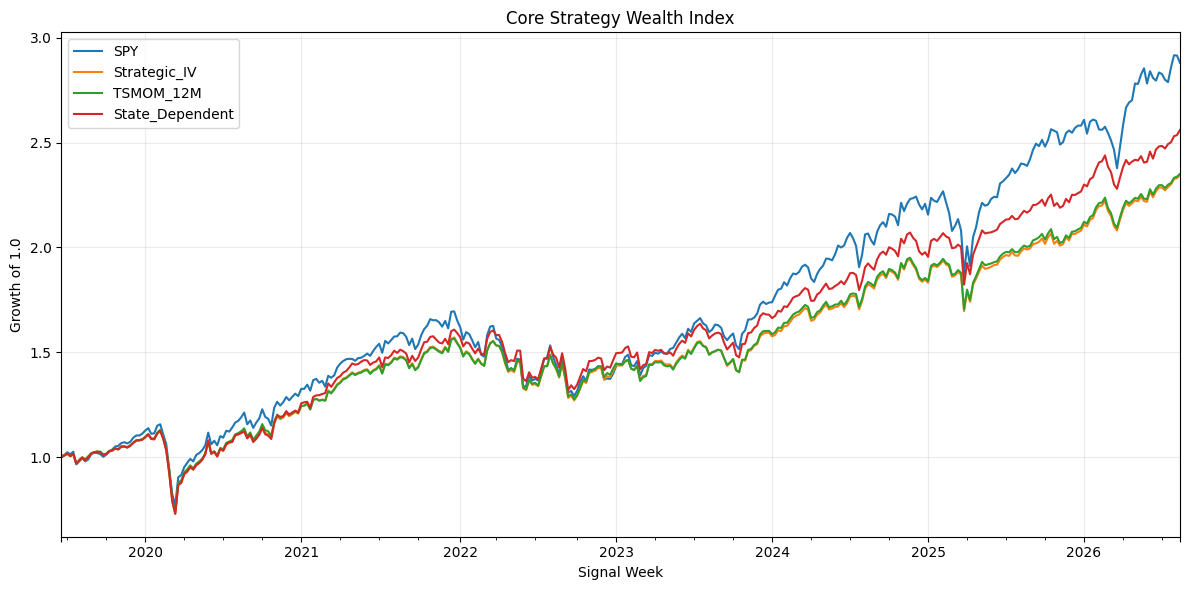

In [4]:
# ============================================================
# BLOCK 7.4 — FIGURE 1: CORE WEALTH INDEX
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

wealth.plot(ax=ax)

ax.set_title("Core Strategy Wealth Index")
ax.set_xlabel("Signal Week")
ax.set_ylabel("Growth of 1.0")
ax.grid(True, alpha=0.25)

fig.tight_layout()

FIG1 = DIRS["figures"] / "block_7_core_wealth_index.png"
fig.savefig(FIG1, dpi=180, bbox_inches="tight")
plt.show()


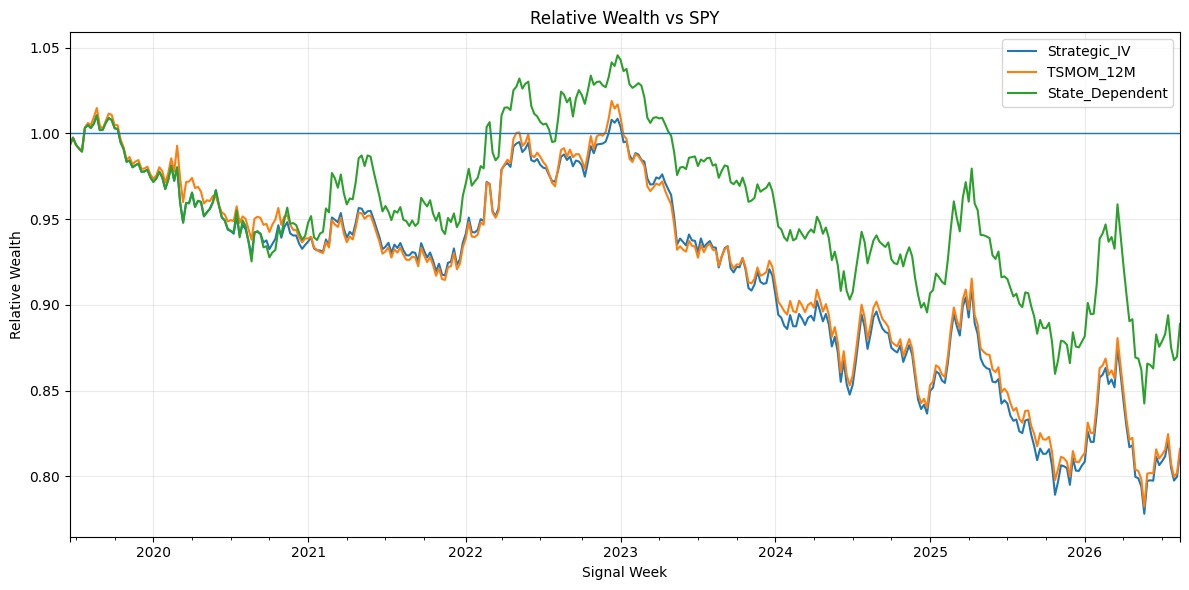

In [5]:
# ============================================================
# BLOCK 7.5 — FIGURE 2: RELATIVE WEALTH VS SPY
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

relative_wealth_vs_spy[
    ["Strategic_IV", "TSMOM_12M", "State_Dependent"]
].plot(ax=ax)

ax.axhline(1.0, linewidth=1)
ax.set_title("Relative Wealth vs SPY")
ax.set_xlabel("Signal Week")
ax.set_ylabel("Relative Wealth")
ax.grid(True, alpha=0.25)

fig.tight_layout()

FIG2 = DIRS["figures"] / "block_7_relative_wealth_vs_spy.png"
fig.savefig(FIG2, dpi=180, bbox_inches="tight")
plt.show()


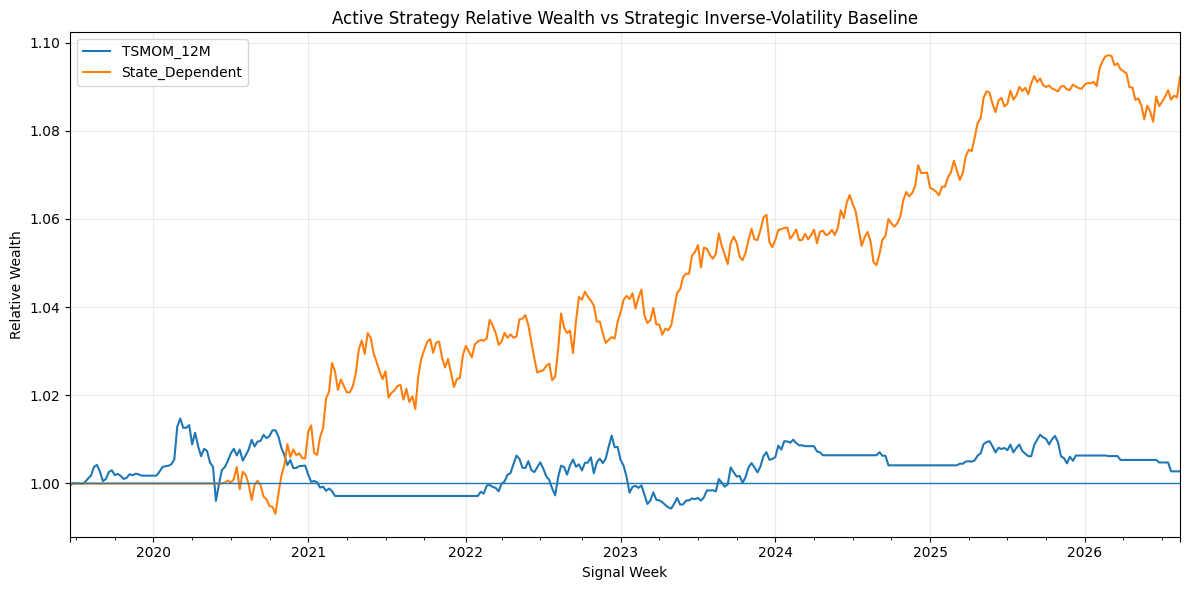

In [6]:
# ============================================================
# BLOCK 7.6 — FIGURE 3: ACTIVE WEALTH VS STRATEGIC BASELINE
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

relative_wealth_vs_strategic[
    ["TSMOM_12M", "State_Dependent"]
].plot(ax=ax)

ax.axhline(1.0, linewidth=1)
ax.set_title("Active Strategy Relative Wealth vs Strategic Inverse-Volatility Baseline")
ax.set_xlabel("Signal Week")
ax.set_ylabel("Relative Wealth")
ax.grid(True, alpha=0.25)

fig.tight_layout()

FIG3 = DIRS["figures"] / "block_7_relative_wealth_vs_strategic.png"
fig.savefig(FIG3, dpi=180, bbox_inches="tight")
plt.show()


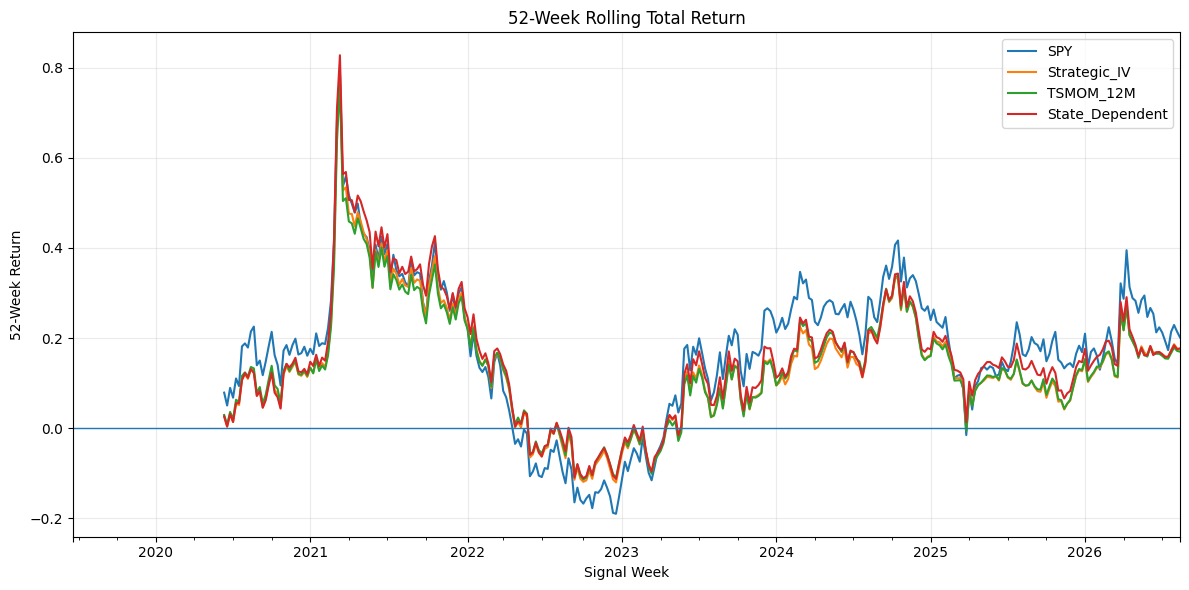

In [7]:
# ============================================================
# BLOCK 7.7 — FIGURE 4: 52-WEEK ROLLING RETURN
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

rolling_return.plot(ax=ax)

ax.axhline(0.0, linewidth=1)
ax.set_title("52-Week Rolling Total Return")
ax.set_xlabel("Signal Week")
ax.set_ylabel("52-Week Return")
ax.grid(True, alpha=0.25)

fig.tight_layout()

FIG4 = DIRS["figures"] / "block_7_rolling_52w_return.png"
fig.savefig(FIG4, dpi=180, bbox_inches="tight")
plt.show()


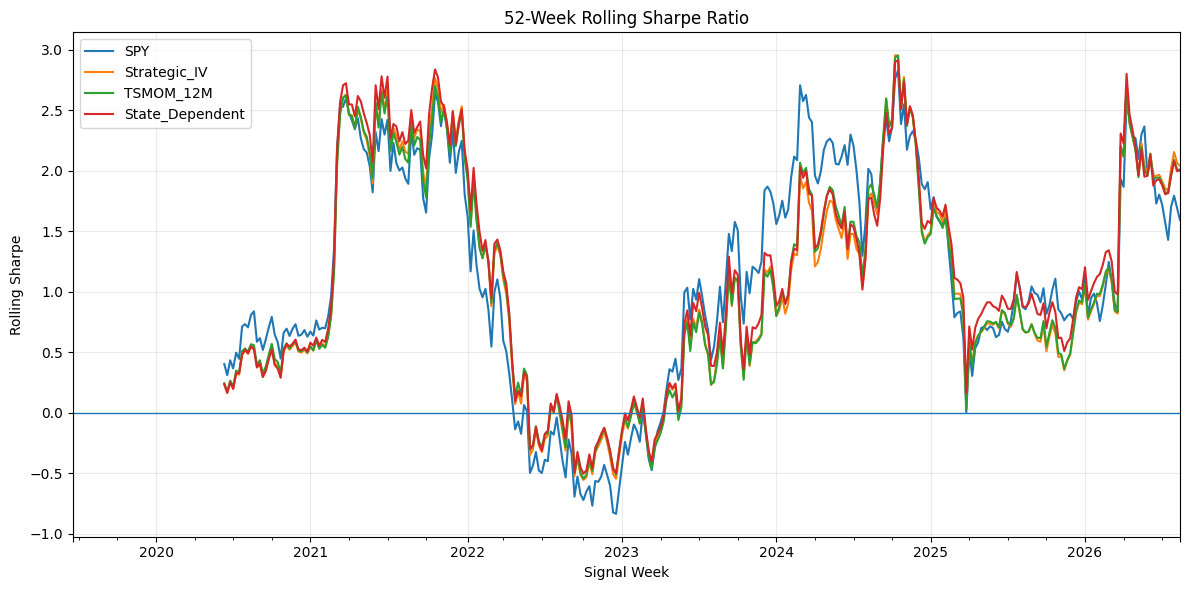

In [8]:
# ============================================================
# BLOCK 7.8 — FIGURE 5: 52-WEEK ROLLING SHARPE
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

rolling_sharpe.plot(ax=ax)

ax.axhline(0.0, linewidth=1)
ax.set_title("52-Week Rolling Sharpe Ratio")
ax.set_xlabel("Signal Week")
ax.set_ylabel("Rolling Sharpe")
ax.grid(True, alpha=0.25)

fig.tight_layout()

FIG5 = DIRS["figures"] / "block_7_rolling_52w_sharpe.png"
fig.savefig(FIG5, dpi=180, bbox_inches="tight")
plt.show()


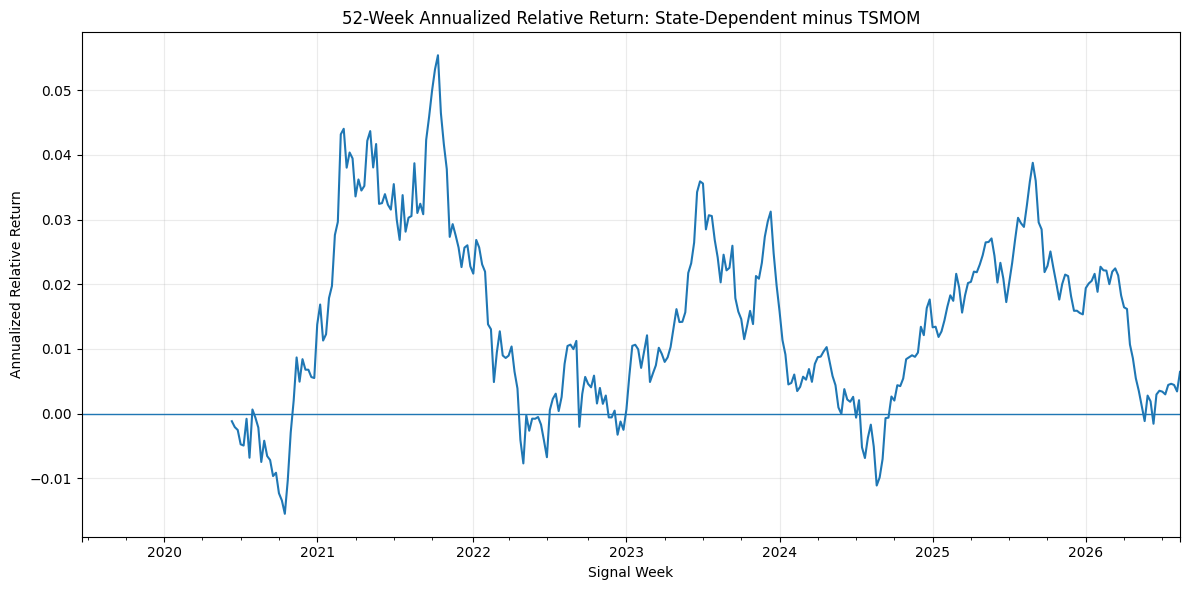

In [9]:
# ============================================================
# BLOCK 7.9 — FIGURE 6: STATE-DEPENDENT VS TSMOM ROLLING EDGE
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

rolling_active_state_vs_tsmom.plot(ax=ax)

ax.axhline(0.0, linewidth=1)
ax.set_title("52-Week Annualized Relative Return: State-Dependent minus TSMOM")
ax.set_xlabel("Signal Week")
ax.set_ylabel("Annualized Relative Return")
ax.grid(True, alpha=0.25)

fig.tight_layout()

FIG6 = DIRS["figures"] / "block_7_state_minus_tsmom_rolling_edge.png"
fig.savefig(FIG6, dpi=180, bbox_inches="tight")
plt.show()


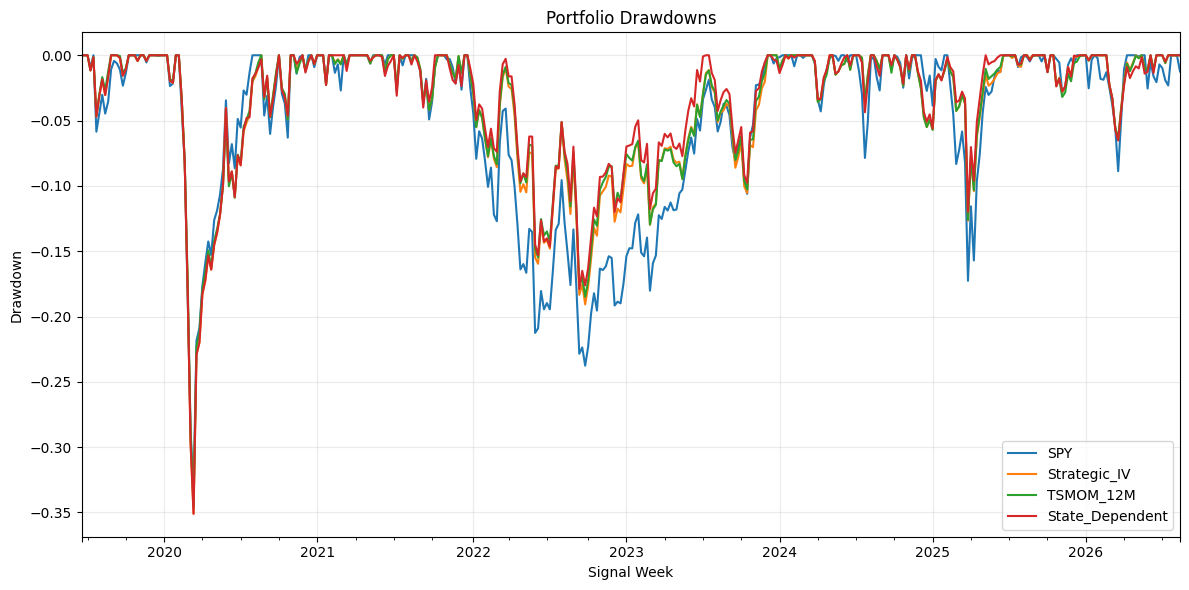

In [10]:
# ============================================================
# BLOCK 7.10 — FIGURE 7: DRAWDOWNS
# ============================================================

def drawdown_series(r: pd.Series) -> pd.Series:
    w = (1.0 + r).cumprod()
    return w / w.cummax() - 1.0


drawdowns = pd.DataFrame(
    {
        name: drawdown_series(portfolio_returns[name])
        for name in EXPECTED_PORTFOLIOS
    }
)

fig, ax = plt.subplots(figsize=(12, 6))

drawdowns.plot(ax=ax)

ax.set_title("Portfolio Drawdowns")
ax.set_xlabel("Signal Week")
ax.set_ylabel("Drawdown")
ax.grid(True, alpha=0.25)

fig.tight_layout()

FIG7 = DIRS["figures"] / "block_7_drawdowns.png"
fig.savefig(FIG7, dpi=180, bbox_inches="tight")
plt.show()


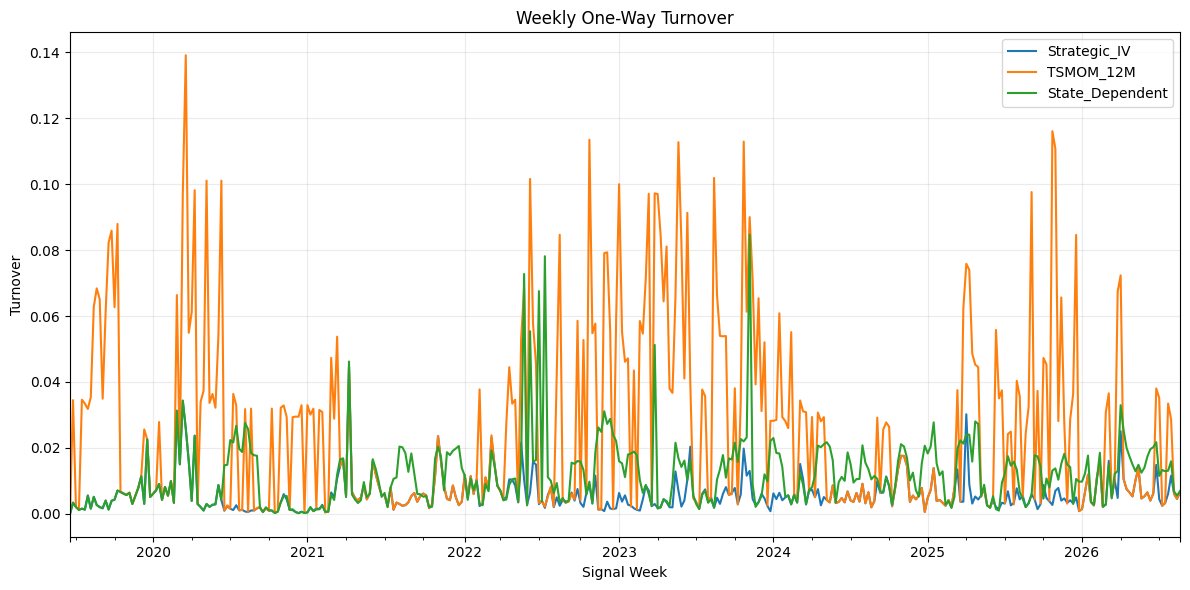

In [11]:
# ============================================================
# BLOCK 7.11 — FIGURE 8: WEEKLY TURNOVER
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

turnover.plot(ax=ax)

ax.set_title("Weekly One-Way Turnover")
ax.set_xlabel("Signal Week")
ax.set_ylabel("Turnover")
ax.grid(True, alpha=0.25)

fig.tight_layout()

FIG8 = DIRS["figures"] / "block_7_weekly_turnover.png"
fig.savefig(FIG8, dpi=180, bbox_inches="tight")
plt.show()


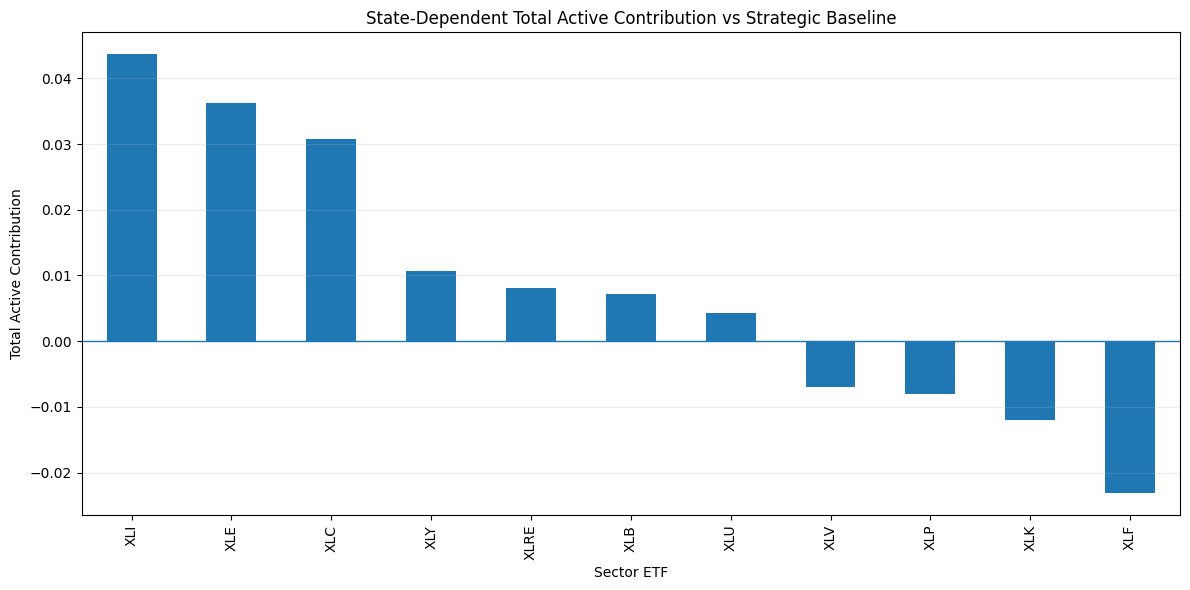

In [12]:
# ============================================================
# BLOCK 7.12 — FIGURE 9: SECTOR ATTRIBUTION
# ============================================================

sector_total_contrib = (
    state_sector_contrib
    .sum(axis=0)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 6))

sector_total_contrib.plot(kind="bar", ax=ax)

ax.axhline(0.0, linewidth=1)
ax.set_title("State-Dependent Total Active Contribution vs Strategic Baseline")
ax.set_xlabel("Sector ETF")
ax.set_ylabel("Total Active Contribution")
ax.grid(True, axis="y", alpha=0.25)

fig.tight_layout()

FIG9 = DIRS["figures"] / "block_7_sector_active_contribution.png"
fig.savefig(FIG9, dpi=180, bbox_inches="tight")
plt.show()


## State-conditioned diagnostics

The state-dependent model should not be interpreted only through aggregate returns. We also want to understand whether the active portfolio behaved differently depending on the indicator's strategic and tactical regimes.

The following tables map each realized signal week to the state information available when those target weights were created.


In [13]:
# ============================================================
# BLOCK 7.13 — STATE-CONDITIONED ACTIVE RETURN TABLES
# ============================================================

realized_weeks = portfolio_returns.index

state_realized = (
    state_weight_long[
        state_weight_long["date"].isin(realized_weeks)
    ]
    .copy()
)

# Build a robust date/active-return table irrespective of the
# original index name used by Block 5.
state_active_return_df = (
    state_minus_strategic
    .rename("state_active_return")
    .to_frame()
    .reset_index()
)

# The first column after reset_index() is the signal-week index.
state_active_return_df = state_active_return_df.rename(
    columns={state_active_return_df.columns[0]: "date"}
)
state_active_return_df["date"] = pd.to_datetime(
    state_active_return_df["date"]
)

state_realized = state_realized.merge(
    state_active_return_df,
    on="date",
    how="left",
    validate="many_to_one",
)

if state_realized["state_active_return"].isna().any():
    raise ValueError(
        "Missing state active returns after date merge."
    )

# Cross-sectional state composition by week.
strategic_state_share = (
    state_realized
    .groupby(["date", "strategic_state"])
    .size()
    .unstack(fill_value=0)
    .div(len(SECTOR_TICKERS))
)

tactical_state_share = (
    state_realized
    .groupby(["date", "tactical_state"])
    .size()
    .unstack(fill_value=0)
    .div(len(SECTOR_TICKERS))
)

# Aggregate portfolio active return conditioned on whether a state is present.
condition_rows = []

for state_name in [
    "BEARISH",
    "EARLY_REVERSAL",
    "CONFIRMED_TREND",
    "NORMAL_POSITIVE_TREND",
]:
    if state_name in strategic_state_share.columns:
        presence = strategic_state_share[state_name] > 0
        r = state_minus_strategic.reindex(presence.index)[presence]

        condition_rows.append(
            {
                "Condition": f"Strategic state present: {state_name}",
                "Weeks": int(presence.sum()),
                "Mean Weekly Active Return": r.mean(),
                "Annualized Mean Active Return": r.mean() * 52,
                "Positive Active Weeks": (r > 0).mean(),
            }
        )

for state_name in [
    "PULLBACK_ACCUMULATION",
    "PROFIT_TAKING",
]:
    if state_name in tactical_state_share.columns:
        presence = tactical_state_share[state_name] > 0
        r = state_minus_strategic.reindex(presence.index)[presence]

        condition_rows.append(
            {
                "Condition": f"Tactical state present: {state_name}",
                "Weeks": int(presence.sum()),
                "Mean Weekly Active Return": r.mean(),
                "Annualized Mean Active Return": r.mean() * 52,
                "Positive Active Weeks": (r > 0).mean(),
            }
        )

if not condition_rows:
    raise ValueError(
        "No recognized strategic/tactical states were found "
        "in the realized sample."
    )

state_condition_summary = (
    pd.DataFrame(condition_rows)
    .set_index("Condition")
)

display(state_condition_summary)


,Weeks,Mean Weekly Active Return,Annualized Mean Active Return,Positive Active Weeks
Condition,,,,
Strategic state present: BEARISH,374,0.000243,0.012645,0.489305
Strategic state present: EARLY_REVERSAL,158,0.000339,0.017622,0.550633
Strategic state present: CONFIRMED_TREND,14,0.000749,0.038935,0.500000
Strategic state present: NORMAL_POSITIVE_TREND,317,0.000275,0.014298,0.545741
Tactical state present: PULLBACK_ACCUMULATION,129,0.000465,0.024192,0.573643
Tactical state present: PROFIT_TAKING,286,0.000250,0.012979,0.548951


In [14]:
# ============================================================
# BLOCK 7.14 — ACTIVE-MULTIPLIER DISTRIBUTION
# ============================================================

active_distribution = (
    state_weight_long[
        state_weight_long["date"].isin(realized_weeks)
    ]["active_multiplier"]
    .value_counts()
    .sort_index()
    .rename("week_sector_rows")
    .to_frame()
)

active_distribution["share"] = (
    active_distribution["week_sector_rows"]
    / active_distribution["week_sector_rows"].sum()
)

display(active_distribution)


,week_sector_rows,share
active_multiplier,,
-5.000000e-01,2052,0.498785
-4.000000e-01,17,0.004132
-3.000000e-01,17,0.004132
-2.000000e-01,17,0.004132
-1.000000e-01,17,0.004132
-2.775558e-17,15,0.003646
0.000000e+00,1233,0.299708
2.775558e-17,22,0.005348
1.000000e-01,31,0.007535


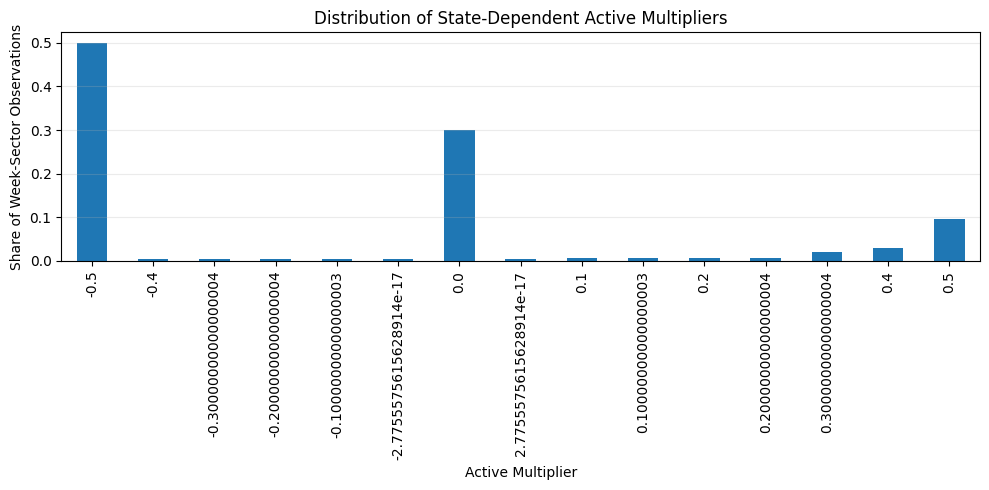

In [15]:
# ============================================================
# BLOCK 7.15 — FIGURE 10: ACTIVE-MULTIPLIER DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

active_distribution["share"].plot(kind="bar", ax=ax)

ax.set_title("Distribution of State-Dependent Active Multipliers")
ax.set_xlabel("Active Multiplier")
ax.set_ylabel("Share of Week-Sector Observations")
ax.grid(True, axis="y", alpha=0.25)

fig.tight_layout()

FIG10 = DIRS["figures"] / "block_7_active_multiplier_distribution.png"
fig.savefig(FIG10, dpi=180, bbox_inches="tight")
plt.show()


In [16]:
# ============================================================
# BLOCK 7.16 — TOP / BOTTOM ACTIVE WEEKS
# ============================================================

diagnostic_weeks = pd.DataFrame(
    {
        "State_vs_Strategic": state_minus_strategic,
        "TSMOM_vs_Strategic": tsmom_minus_strategic,
        "State_vs_TSMOM": state_minus_tsmom,
        "SPY": portfolio_returns["SPY"],
        "State_Dependent": portfolio_returns["State_Dependent"],
    }
)

top_state_vs_tsmom = (
    diagnostic_weeks
    .nlargest(10, "State_vs_TSMOM")
)

bottom_state_vs_tsmom = (
    diagnostic_weeks
    .nsmallest(10, "State_vs_TSMOM")
)

print("Top 10 State-Dependent vs TSMOM weeks:")
display(top_state_vs_tsmom)

print("Bottom 10 State-Dependent vs TSMOM weeks:")
display(bottom_state_vs_tsmom)


Top 10 State-Dependent vs TSMOM weeks:


,State_vs_Strategic,TSMOM_vs_Strategic,State_vs_TSMOM,SPY,State_Dependent
Date,,,,,
2022-09-23,7.131020e-03,-0.001646,0.008777,0.006313,0.016859
2021-01-01,6.223294e-03,-0.002058,0.008281,0.026845,0.035200
2020-05-29,2.775558e-17,-0.008233,0.008233,0.057765,0.065450
2021-02-12,6.610929e-03,-0.000947,0.007558,-0.013434,0.000861
2021-09-17,7.467614e-03,0.000000,0.007468,0.019814,0.021686
2020-10-30,4.373521e-03,-0.002724,0.007097,0.073774,0.069883
2020-11-13,4.662861e-03,-0.002271,0.006934,-0.014094,-0.006481
2021-02-26,6.348232e-03,-0.000576,0.006924,-0.020175,0.003386
2020-07-31,4.075845e-03,-0.002554,0.006630,0.020621,0.031316


Bottom 10 State-Dependent vs TSMOM weeks:


,State_vs_Strategic,TSMOM_vs_Strategic,State_vs_TSMOM,SPY,State_Dependent
Date,,,,,
2020-02-28,0.000000,0.006620,-0.006620,-0.112783,-0.105652
2021-01-15,-0.006232,0.000205,-0.006437,0.015159,0.001902
2020-07-24,-0.005042,0.001346,-0.006388,0.017233,0.000585
2022-11-11,-0.003512,0.002484,-0.005996,-0.001341,0.000261
2022-09-16,-0.004591,0.001226,-0.005816,-0.062386,-0.072361
2020-08-21,-0.003561,0.002190,-0.005751,0.018634,0.006324
2021-07-09,-0.005696,0.000000,-0.005696,-0.027706,-0.030973
2024-08-23,-0.004442,0.000000,-0.004442,-0.015531,-0.008683
2023-07-14,-0.004872,-0.000624,-0.004248,0.007453,0.011403


In [17]:
# ============================================================
# BLOCK 7.17 — RESEARCH INTERPRETATION SUMMARY
# ============================================================

perf = pd.read_csv(
    block6["saved_files"]["performance_summary"],
    index_col=0,
)

rel = pd.read_csv(
    block6["saved_files"]["state_vs_tsmom"],
    index_col=0,
)

state_cagr = perf.loc["State_Dependent", "CAGR"]
tsmom_cagr = perf.loc["TSMOM_12M", "CAGR"]
spy_cagr = perf.loc["SPY", "CAGR"]
strategic_cagr = perf.loc["Strategic_IV", "CAGR"]

state_sharpe = perf.loc["State_Dependent", "Sharpe"]
tsmom_sharpe = perf.loc["TSMOM_12M", "Sharpe"]

state_mdd = perf.loc["State_Dependent", "Max Drawdown"]
tsmom_mdd = perf.loc["TSMOM_12M", "Max Drawdown"]

interpretation = pd.Series(
    {
        "State CAGR": state_cagr,
        "TSMOM CAGR": tsmom_cagr,
        "Strategic IV CAGR": strategic_cagr,
        "SPY CAGR": spy_cagr,
        "State minus TSMOM CAGR spread": state_cagr - tsmom_cagr,
        "State Sharpe": state_sharpe,
        "TSMOM Sharpe": tsmom_sharpe,
        "State minus TSMOM Sharpe": state_sharpe - tsmom_sharpe,
        "State Max Drawdown": state_mdd,
        "TSMOM Max Drawdown": tsmom_mdd,
        "State drawdown improvement vs TSMOM": tsmom_mdd - state_mdd,
    },
    name="Research interpretation inputs",
).to_frame()

display(interpretation)


,Research interpretation inputs
State CAGR,0.140125
TSMOM CAGR,0.126613
Strategic IV CAGR,0.126183
SPY CAGR,0.159001
State minus TSMOM CAGR spread,0.013511
State Sharpe,0.840655
TSMOM Sharpe,0.788368
State minus TSMOM Sharpe,0.052287
State Max Drawdown,-0.351040
TSMOM Max Drawdown,-0.345465


In [18]:
# ============================================================
# BLOCK 7.18 — SAVE DIAGNOSTIC TABLES
# ============================================================

STATE_CONDITION_PATH = (
    DIRS["tables"] / "block_7_state_condition_summary.csv"
)

ACTIVE_DIST_PATH = (
    DIRS["tables"] / "block_7_active_multiplier_distribution.csv"
)

TOP_WEEKS_PATH = (
    DIRS["tables"] / "block_7_top_state_vs_tsmom_weeks.csv"
)

BOTTOM_WEEKS_PATH = (
    DIRS["tables"] / "block_7_bottom_state_vs_tsmom_weeks.csv"
)

INTERPRETATION_INPUT_PATH = (
    DIRS["tables"] / "block_7_research_interpretation_inputs.csv"
)

state_condition_summary.to_csv(STATE_CONDITION_PATH)
active_distribution.to_csv(ACTIVE_DIST_PATH)
top_state_vs_tsmom.to_csv(TOP_WEEKS_PATH)
bottom_state_vs_tsmom.to_csv(BOTTOM_WEEKS_PATH)
interpretation.to_csv(INTERPRETATION_INPUT_PATH)

print("Saved Block 7 diagnostic tables.")


Saved Block 7 diagnostic tables.


In [19]:
# ============================================================
# BLOCK 7.19 — SAVE BLOCK 7 MANIFEST
# ============================================================

block7_manifest = {
    "project": block1["project"],
    "block": "Block 7 - Visual Diagnostics & Research Interpretation",
    "created_utc": datetime.now(timezone.utc).isoformat(),

    "rolling_window_weeks": ROLLING_WINDOW,

    "figures": {
        "core_wealth_index": str(FIG1),
        "relative_wealth_vs_spy": str(FIG2),
        "relative_wealth_vs_strategic": str(FIG3),
        "rolling_52w_return": str(FIG4),
        "rolling_52w_sharpe": str(FIG5),
        "state_minus_tsmom_rolling_edge": str(FIG6),
        "drawdowns": str(FIG7),
        "weekly_turnover": str(FIG8),
        "sector_active_contribution": str(FIG9),
        "active_multiplier_distribution": str(FIG10),
    },

    "tables": {
        "state_condition_summary": str(STATE_CONDITION_PATH),
        "active_multiplier_distribution": str(ACTIVE_DIST_PATH),
        "top_state_vs_tsmom_weeks": str(TOP_WEEKS_PATH),
        "bottom_state_vs_tsmom_weeks": str(BOTTOM_WEEKS_PATH),
        "research_interpretation_inputs": str(INTERPRETATION_INPUT_PATH),
    },

    "interpretation_scope": [
        "Persistence of relative performance",
        "Rolling return and Sharpe behaviour",
        "Drawdown comparison",
        "Turnover comparison",
        "Sector contribution concentration",
        "State-conditioned active performance",
        "Best and worst relative weeks",
    ],
}

BLOCK7_MANIFEST = (
    DIRS["manifests"] / "block_7_visual_diagnostics.json"
)

with open(BLOCK7_MANIFEST, "w", encoding="utf-8") as f:
    json.dump(block7_manifest, f, indent=2)

print("Saved Block 7 manifest:")
print(BLOCK7_MANIFEST)


Saved Block 7 manifest:
/content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation/manifests/block_7_visual_diagnostics.json


In [20]:
# ============================================================
# BLOCK 7.20 — FINAL STATUS
# ============================================================

figure_paths = [
    FIG1,
    FIG2,
    FIG3,
    FIG4,
    FIG5,
    FIG6,
    FIG7,
    FIG8,
    FIG9,
    FIG10,
]

summary = pd.Series(
    {
        "Portfolios visualized": len(EXPECTED_PORTFOLIOS),
        "Realized weekly observations": len(portfolio_returns),
        "Rolling diagnostic window": ROLLING_WINDOW,
        "Figures created": len(figure_paths),
        "All figures saved": all(p.exists() for p in figure_paths),
        "State-conditioned table created": STATE_CONDITION_PATH.exists(),
        "Active multiplier table created": ACTIVE_DIST_PATH.exists(),
        "Top/bottom relative weeks saved": (
            TOP_WEEKS_PATH.exists()
            and BOTTOM_WEEKS_PATH.exists()
        ),
        "Research interpretation inputs saved": (
            INTERPRETATION_INPUT_PATH.exists()
        ),
    },
    name="Block 7 status",
).to_frame()

display(summary)

print("\nBLOCK 7 COMPLETE")
print(
    "Next: Research interpretation, robustness tests, "
    "and final report construction"
)


,Block 7 status
Portfolios visualized,4
Realized weekly observations,374
Rolling diagnostic window,52
Figures created,10
All figures saved,True
State-conditioned table created,True
Active multiplier table created,True
Top/bottom relative weeks saved,True
Research interpretation inputs saved,True



BLOCK 7 COMPLETE
Next: Research interpretation, robustness tests, and final report construction
